# LII Congreso Nacional de Psicología CNEIP 2026
# Métodos para Analizar Oscilaciones Neuronales y Actividad Aperiódica

La primera parte del taller (Procesamiento de Señales Digitales y Simulaciones) consta de 2 partes separadas en 2 notebooks. El primer notebook (este) mostrará cómo cambian los espectros de potencia (power spectra) según la señal temporal simulada. El segundo notebook explorará los fundamentos del filtrado (filtering) y cómo este puede alterar tus datos, para que puedas tenerlo en cuenta en tus propios análisis. A continuación se presentan los temas considerados en este notebook:

- Espectros de potencia (Power Spectra)
    - Función delta
    - Ruido blanco
- Oscilaciones sinusoidales
    - Una oscilación
    - Varias oscilaciones
    - Muchas oscilaciones
- Oscilaciones no estacionarias (bursts)
- Oscilaciones no sinusoidales
- Oscilaciones incrustadas en actividad aperiódica

## Lección 1: Procesamiento de Señales Digitales y Simulaciones

En este notebook revisaremos algunas funciones para simular tus propios datos usando la librería NeuroDSP
(https://neurodsp-tools.github.io/neurodsp/index.html)

### Preparación

In [1]:
# Instalar paquetes necesarios (para Colab)
!pip install neurodsp

#### Paquetes

In [2]:
# general 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal

# herramientas del Voytek Lab
from neurodsp import spectral
from neurodsp import filt
from neurodsp import sim
from neurodsp import utils

#### Configuración

In [ ]:
# parámetros de la señal
N_SECONDS = 100 # duración de la señal
FS = 1000 # frecuencia de muestreo

In [4]:
# parámetros de graficación

# tamaño de fuente
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 10

# color
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['axes.facecolor'] = 'w'

#### Funciones

In [ ]:
def plot_signal_and_power(time, signal, freq, spectrum, title='', logscale=False, xlims=None):
    '''
    Grafica una serie temporal y su espectro de potencia (power spectrum) correspondiente

    Parámetros
    ----------
    time : arreglo 1D, float
        vector temporal de la señal
    signal : arreglo 1D, float
        serie temporal, por ejemplo LFP o EEG
    freq : arreglo 1D, float
        vector de frecuencias del spectrum
    spectrum : arreglo 1D, float
        espectro de potencia (power spectrum) de la señal
    title : str, opcional
        título de la figura. El valor predeterminado es ''.
    logscale : bool, opcional
        indica si se grafica el spectrum en espacio log-log. El valor predeterminado es False.
    xlims : arreglo 1D (len=2), opcional
        límites del eje x para la gráfica de la serie temporal ([límite_inferior, límite_superior]). 
        El valor predeterminado es None.

    '''
    # crear figura
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=[12,4], gridspec_kw={'width_ratios': [3, 1]}, constrained_layout=True)
    fig.suptitle(title)

    # graficar señal
    ax1.set(xlabel='time (s)', ylabel='voltage (au)', title='Time-series')
    ax1.plot(time, signal)
    if xlims:
        ax1.set_xlim(xlims)
        
    # graficar spectra
    ax2.set(xlabel='frequency (Hz)', ylabel='power (au)', title='Power Spectral Density')
    ax2.plot(freq, spectrum);
    ax2.set_xlim([.1,200])
    if logscale:
        ax2.set(xscale='log', yscale='log')


### Espectros de potencia de señales simples:
Primero simularemos una función delta de Dirac y un proceso de ruido blanco.

#### Función delta de Dirac

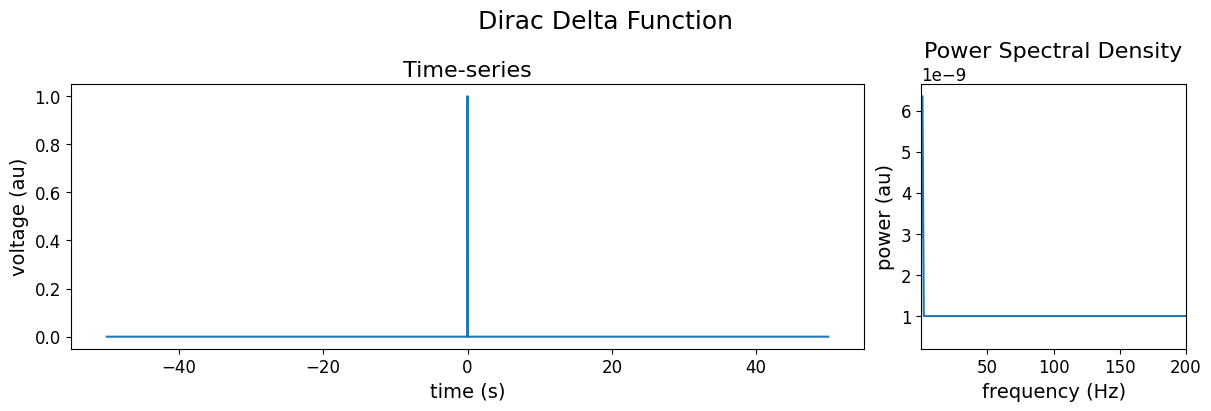

In [6]:
# simular función delta de Dirac
dirac = np.zeros(utils.data.compute_nsamples(N_SECONDS, FS)) # crear arreglo de ceros
dirac[int(len(dirac)/2)] = 1 # fijar el valor central en 1
time = utils.create_times(N_SECONDS, FS, start_val=-N_SECONDS/2)

# calcular espectro de potencia
freq, psd_dirac = spectral.compute_spectrum(dirac, FS)

# graficar
plot_signal_and_power(time, dirac, freq, psd_dirac, title='Dirac Delta Function')

Vemos que esta función simple está asociada con potencia distinta de cero en todas las frecuencias.

#### Señal de ruido blanco

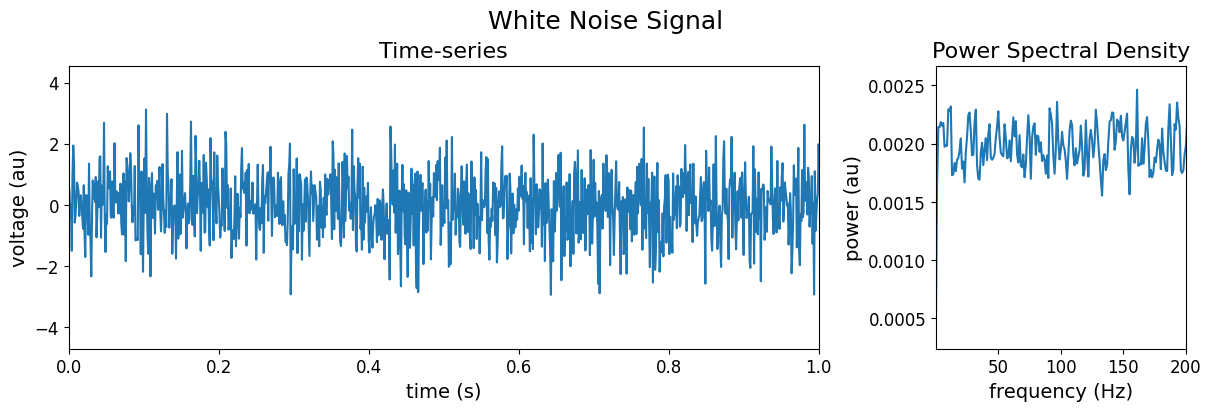

In [18]:
# simular señal de ruido blanco
signal_white = np.random.normal(loc=0, scale=1, size=utils.data.compute_nsamples(N_SECONDS, FS))
time = utils.create_times(N_SECONDS, FS)

# calcular espectro de potencia de la señal de ruido blanco
_, psd_white = spectral.compute_spectrum(signal_white, FS)

# graficar
plot_signal_and_power(time, signal_white, freq, psd_white, title='White Noise Signal', xlims=[0,1])

Vemos que las señales de ruido blanco tienen aproximadamente la misma potencia en todas las frecuencias. Al igual que en la simulación anterior, cada banda de frecuencia muestra algo de potencia aunque no haya una oscilación presente. Estas simulaciones resaltan que observar potencia en una banda de frecuencia específica por sí sola no constituye evidencia de una oscilación neural.

### Oscilaciones sinusoidales
Ahora simularemos señales sinusoidales y señales compuestas por múltiples oscilaciones.

#### simular una oscilación sinusoidal

In [19]:
# configuración
freq_oscillation = 10 # frecuencia pico de la oscilación

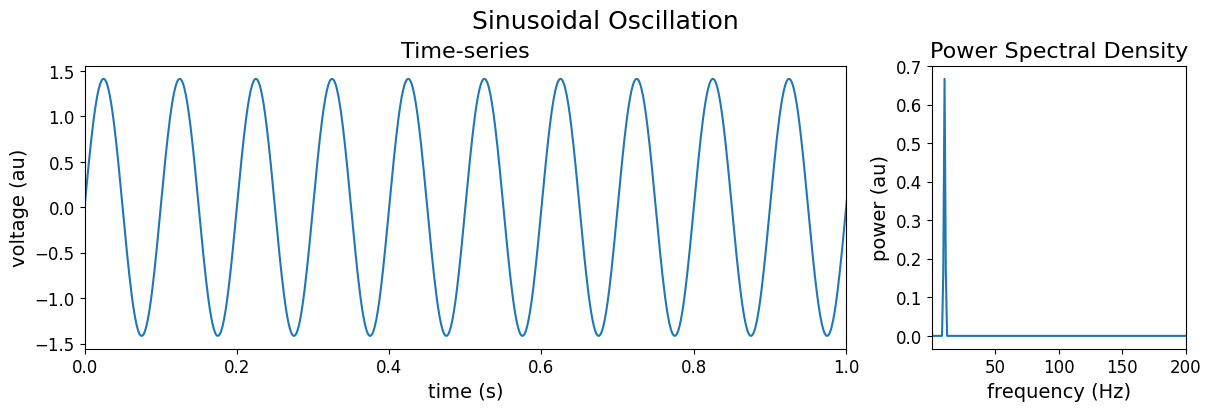

In [20]:
# simular una oscilación sinusoidal
signal_sin = sim.sim_oscillation(N_SECONDS, FS, freq_oscillation)

# calcular espectro de potencia
_, psd_sin = spectral.compute_spectrum(signal_sin, FS)

# graficar
plot_signal_and_power(time, signal_sin, freq, psd_sin, title='Sinusoidal Oscillation', xlims=[0,1])

Vemos que las senoidales están asociadas con potencia dentro de una banda de frecuencia estrecha. Aquí observamos un pico en el espectro de potencia (power spectrum) en la frecuencia de la oscilación. Intenta cambiar el valor de `freq_oscillation` y observa el efecto sobre el espectro de potencia.

#### simular una señal que contiene *varias* oscilaciones sinusoidales

In [21]:
# configuración
freq_oscillations = [10, 35, 60] # frecuencia pico de la oscilación

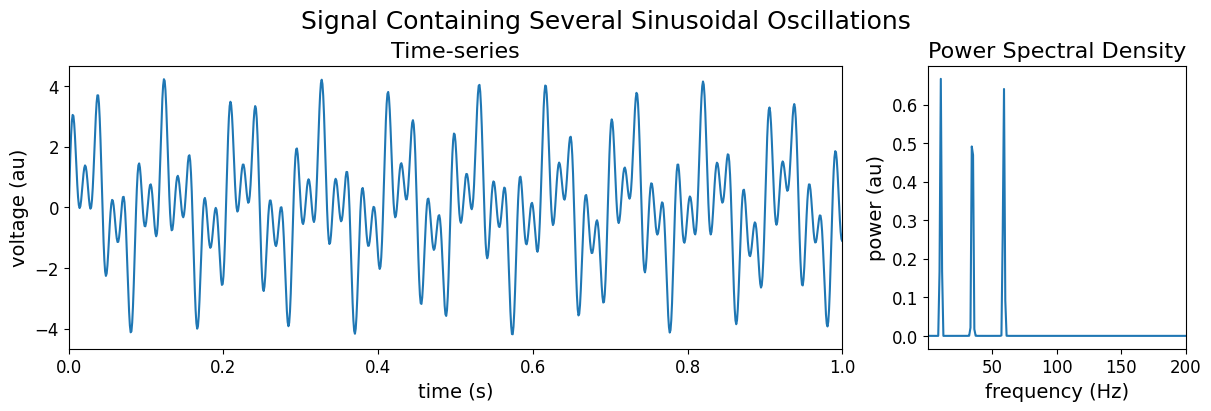

In [22]:
# simular señal
signal_sins = np.zeros_like(time)
for i_osc in range(len(freq_oscillations)):
    signal_sins += sim.sim_oscillation(N_SECONDS, FS, freq_oscillations[i_osc])

# calcular espectro de potencia
_, psd_sins = spectral.compute_spectrum(signal_sins, FS)

# graficar
plot_signal_and_power(time, signal_sins, freq, psd_sins, 
    title='Signal Containing Several Sinusoidal Oscillations', xlims=[0,1])

#### simular una señal que contiene *muchas* (10) oscilaciones sinusoidales

In [23]:
# configuración
osc_freq = np.random.rand(10)*100 # frecuencia pico de la oscilación
osc_amp = np.random.rand(10) # amplitud de la oscilación

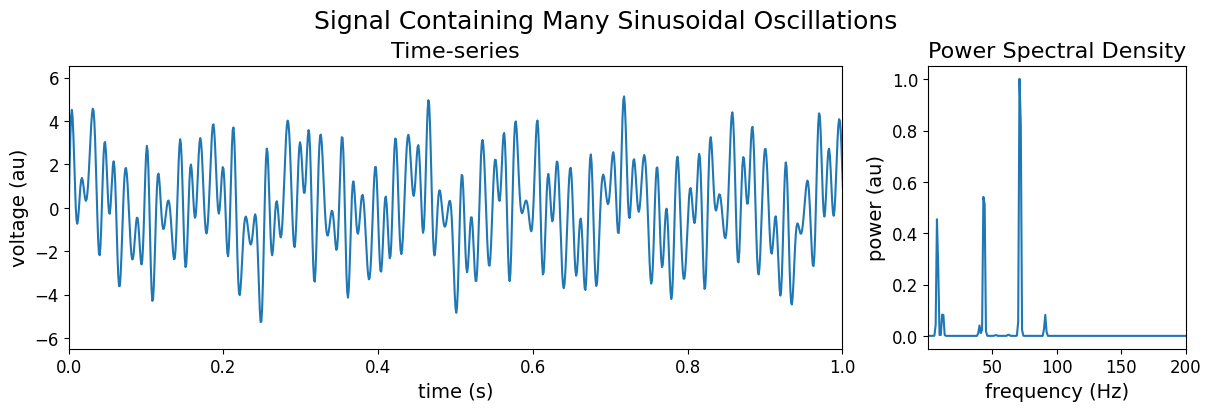

In [24]:
# simular señal
signal_sins2 = np.zeros_like(time)
for i_osc in range(len(osc_freq)):
    signal_sins2 += sim.sim_oscillation(N_SECONDS, FS, osc_freq[i_osc]) * osc_amp[i_osc]

# calcular espectro de potencia
_, psd_sins2 = spectral.compute_spectrum(signal_sins2, FS)

# graficar
plot_signal_and_power(time, signal_sins2, freq, psd_sins2, 
    title='Signal Containing Many Sinusoidal Oscillations', xlims=[0,1])

A pesar de que la señal parece 'compleja', vemos que la potencia sigue concentrada dentro de bandas de frecuencia estrechas, determinadas por `osc_freq`.

### Oscilaciones no estacionarias (bursts)

Ahora simularemos oscilaciones no estacionarias (bursts). Las señales neurales son no estacionarias, es decir, su contenido espectral cambia con el tiempo. Se ha demostrado que las oscilaciones pueden surgir como 'bursts' transitorios que duran desde decenas hasta cientos de milisegundos (ver Stokes and Spaak, 2016; y Jones, 2016).

In [25]:
# configuración
freq_oscillation = 10 # frecuencia pico de la oscilación
cycle = 'sine' # forma de onda de la oscilación

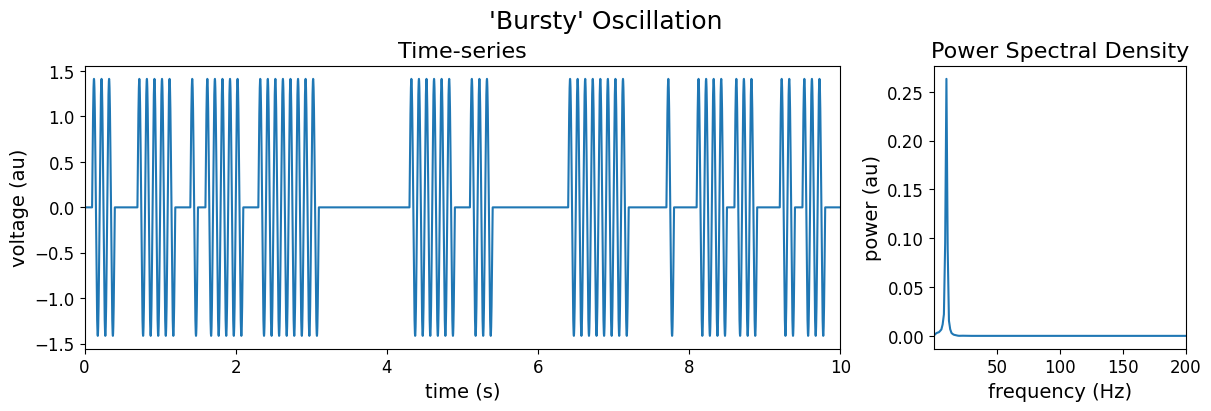

In [26]:
# simular una oscilación no estacionaria
signal_bursty =  sim.sim_bursty_oscillation(n_seconds=N_SECONDS, fs=FS, freq=freq_oscillation, cycle=cycle)

# calcular espectro de potencia
_, psd_bursty = spectral.compute_spectrum(signal_bursty, FS)

# graficar
plot_signal_and_power(time, signal_bursty, freq, psd_bursty, title="'Bursty' Oscillation", xlims=[0,10])

### Oscilaciones no sinusoidales
Ahora simularemos oscilaciones no sinusoidales. Se ha demostrado que los ritmos neurales pueden ser no sinusoidales y a menudo presentan formas tipo 'sawtooth' y otras distorsiones de fase. Estas características de la forma de onda son fisiológicamente relevantes, pero requieren análisis más detallados que exploraremos más adelante en este taller. La Sección 02 explorará un enfoque cycle-by-cycle para estudiar la forma de onda de las oscilaciones neurales.

In [27]:
# configuración
freq_oscillation = 10 # frecuencia pico de la oscilación
cycle = 'sawtooth' # forma de onda de la oscilación
width = 1 # parámetro de la forma de onda sawtooth (0: ascenso rápido. 0.5: simétrica. 1: descenso rápido)

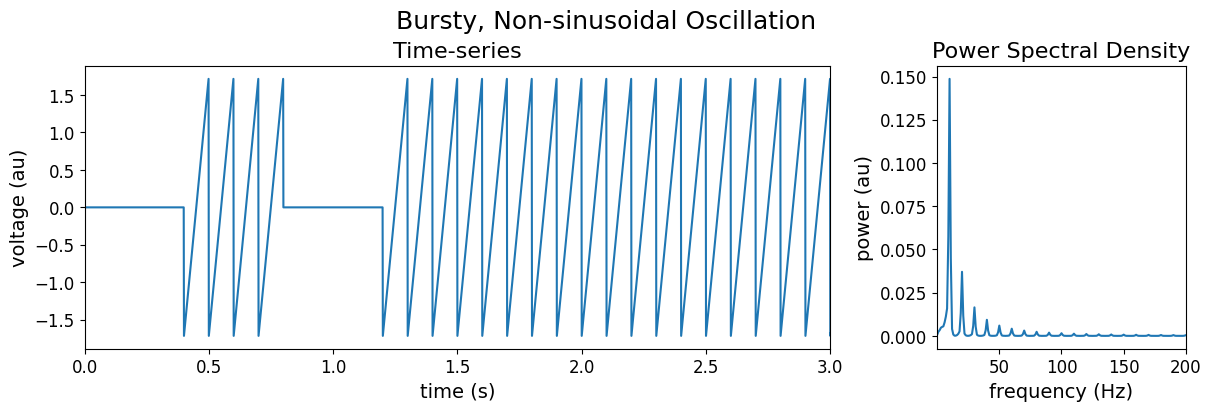

In [28]:
# simular señal
signal_saw =  sim.sim_bursty_oscillation(n_seconds=N_SECONDS, fs=FS, freq=freq_oscillation, cycle=cycle, width=width)

# calcular espectro de potencia
_, psd_saw = spectral.compute_spectrum(signal_saw, FS)

# graficar
plot_signal_and_power(time, signal_saw, freq, psd_saw,
    title='Bursty, Non-sinusoidal Oscillation', xlims=[0,3])

Aquí vemos que la naturaleza no sinusoidal de nuestra señal introduce armónicos en el espectro de potencia (power spectrum). A pesar de que existe un solo ritmo en la frecuencia determinada por `freq_oscillation`, pueden observarse picos adicionales en múltiplos enteros de esa frecuencia.

A continuación, graficaremos ejemplos adicionales de ritmos no sinusoidales y su representación en el dominio de la frecuencia. Todas estas señales tienen la misma frecuencia y amplitud, pero distintas formas de onda.

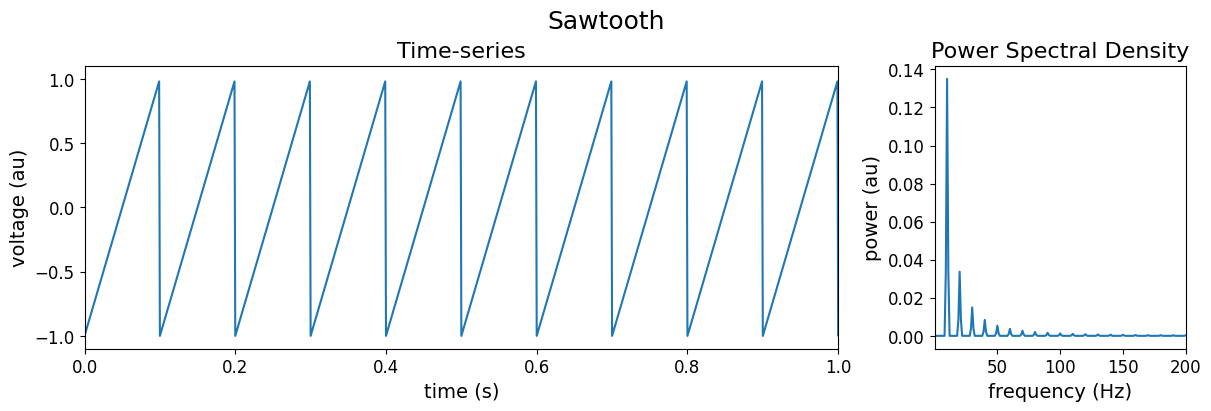

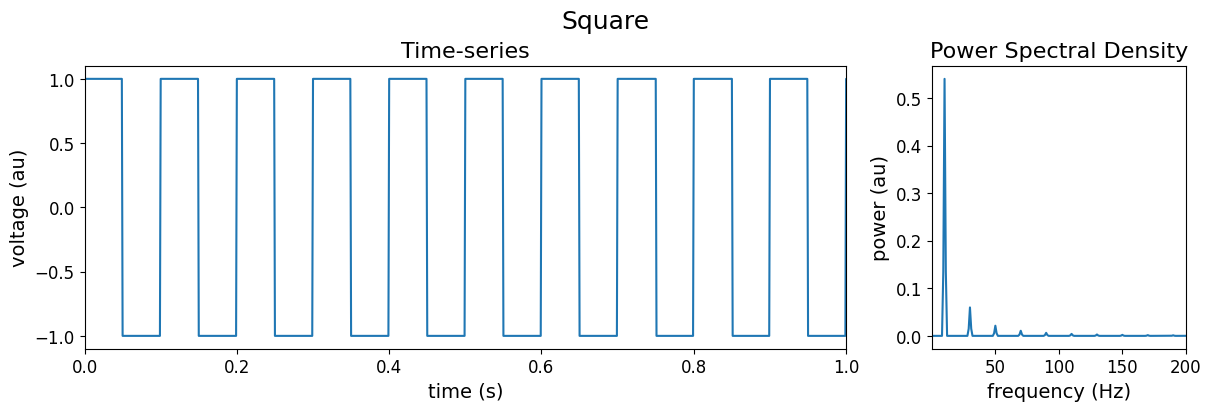

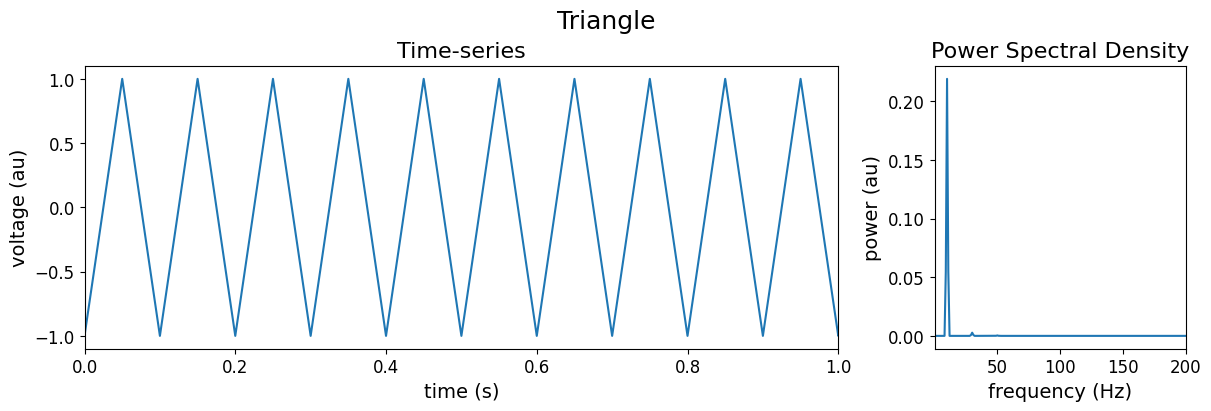

In [29]:
# Simular 3 formas de onda de ejemplo y observar su representación en el dominio de la frecuencia.
# Todas estas señales tienen la misma frecuencia y amplitud, pero distintas formas de onda.

# señal sawtooth
time = np.arange(0, N_SECONDS, 1/FS)
signal_saw = signal.sawtooth(2*np.pi*freq_oscillation*time)
freq, psd_saw = spectral.compute_spectrum(signal_saw, FS)
plot_signal_and_power(time, signal_saw, freq, psd_saw,
    title='Sawtooth', xlims=[0,1])
                      
# señal cuadrada
signal_square = signal.square(2*np.pi*freq_oscillation*time)
_, psd_square = spectral.compute_spectrum(signal_square, FS)
plot_signal_and_power(time, signal_square, freq, psd_square,
    title='Square', xlims=[0,1])

# señal triangular
signal_triangle = signal.sawtooth(2*np.pi*freq_oscillation*time, width=0.5)
_, psd_triangle = spectral.compute_spectrum(signal_triangle, FS)
plot_signal_and_power(time, signal_triangle, freq, psd_triangle,
    title='Triangle', xlims=[0,1])

Estas simulaciones resaltan que un pico en el espectro de potencia (power spectrum) no es necesariamente evidencia de una oscilación en esa frecuencia. Cuando la transformada de Fourier se aplica a una señal no sinusoidal, la representación en frecuencia incluye pseudocomponentes sinusoidales que representan la señal como una sinusoide compleja. Esta representación incorrecta puede llevar a interpretaciones equivocadas de los procesos fisiológicos y cognitivos subyacentes. Además, esto sugiere un problema aún mayor: las funciones basadas en sinusoides son ubicuas en el campo de la neurociencia. La Sección 02 de este taller explorará una solución a este problema: un enfoque cycle-by-cycle para analizar oscilaciones no sinusoidales en el dominio temporal.

### Oscilación incrustada en actividad aperiódica 
Ahora simularemos una oscilación incrustada en actividad aperiódica (o no oscilatoria). Los datos neurales (incluyendo LFP, EEG, ECoG y MEG) muestran contenido espectral tipo 1/f, donde la potencia es inversamente proporcional a la frecuencia. Esto contrasta con las señales de ruido blanco que simulamos antes, donde la potencia era igual en todas las frecuencias. Esta actividad aperiódica es fisiológicamente relevante y debe considerarse al analizar oscilaciones.  

In [30]:
# configuración
sim_components = {'sim_bursty_oscillation': {'freq' : 10},
                  'sim_powerlaw': {'exponent' : -2}} # exponente aperiódico (pendiente espectral)

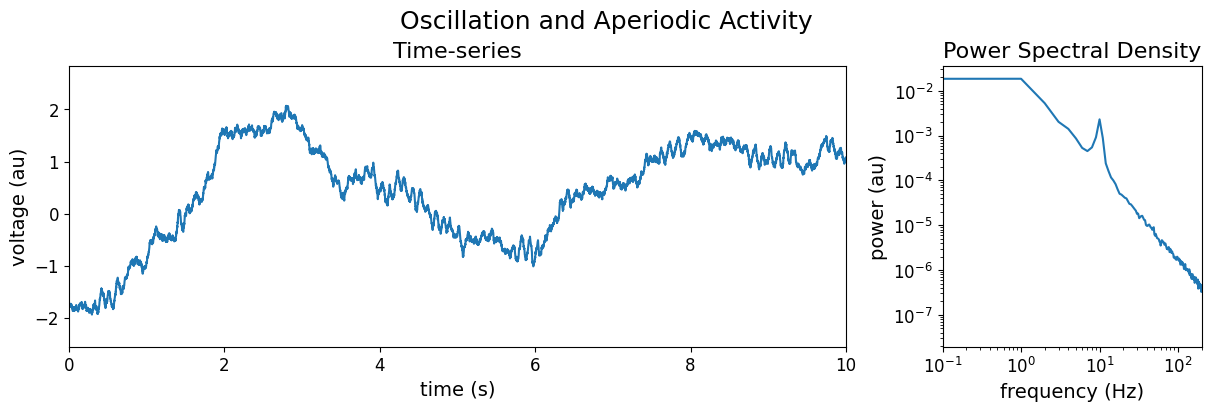

In [31]:
# simular una oscilación sinusoidal incrustada en actividad aperiódica
signal_comb =  sim.sim_combined(n_seconds=N_SECONDS, fs=FS, components=sim_components, component_variances=[1,100])

# calcular espectro de potencia
_, psd_comb = spectral.compute_spectrum(signal_comb, FS)

# graficar
plot_signal_and_power(time, signal_comb, freq, psd_comb,
    title='Oscillation and Aperiodic Activity',
    logscale=True, xlims=[0,10])

Aquí vemos que la señal aperiódica contribuye con potencia en todas las frecuencias, y que la potencia disminuye al aumentar la frecuencia. Al igual que en las simulaciones anteriores, la oscilación sinusoidal contribuye con potencia dentro de una banda de frecuencia estrecha. Una cuantificación cuidadosa de estos componentes es necesaria para analizar sus contribuciones respectivas a la cognición y la conducta.

Conclusion
----------

Este notebook demuestra cómo simular series temporales neurales usando NeuroDSP. Exploramos la relación entre las representaciones en los dominios temporal y de la frecuencia, resaltando algunas limitaciones de los análisis basados en Fourier. Además, introdujimos el tema de la actividad periódica vs. aperiódica, que se explorará con mayor profundidad en la Sección 01, Spectral Parameterization; y presentamos el concepto de la forma de onda, que se explorará con mayor profundidad en la Sección 02, Bycycle.